In [ ]:
# Task: Intent Classification for WVSU Campus Ecosystem
# Domain: Campus Services (Registrar, OSA, MIS, CICT, General)
# Model: distilbert-base-uncased
# Hardware: GTX 1650 Ti (4GB VRAM)

import torch
import evaluate
import numpy as np
from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, 
                          TrainingArguments, Trainer, DataCollatorWithPadding, AutoModel)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download


print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

/home/zim/codes-2026/school/CCS-249_25-26_Activities/BSCS 3A/MACALALAG_QUINCY_RODGE/unit-6-activity/venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA Available: True
Device Name: NVIDIA GeForce GTX 1650 Ti


Checking connection and starting download...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6801.87it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Download Complete!


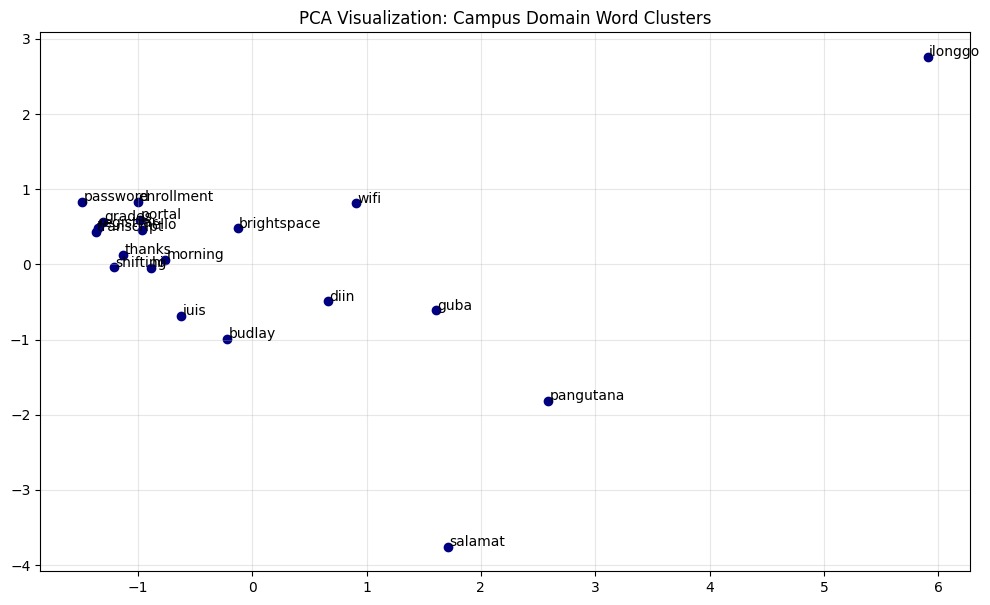

In [4]:

words = ["registrar", "enrollment", "transcript", "grades", "shifting", 
         "iuis", "brightspace", "wifi", "portal", "password",
         "salamat", "hi", "hello", "thanks", "morning",
         "diin", "guba", "budlay", "pangutana", "ilonggo"]

try:
    print("Checking connection and starting download...")
    tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
    model_base = AutoModel.from_pretrained("distilbert-base-uncased")
    print("Download Complete!")
except Exception as e:
    print(f"Error: {e}. Check your internet connection.")


# Extract word embeddings
inputs = tokenizer(words, padding=True, truncation=True, return_tensors="pt")
with torch.no_grad():
    embeddings = model_base(**inputs).last_hidden_state.mean(dim=1).numpy()

# Reduce to 2D
pca = PCA(n_components=2).fit_transform(embeddings)

# Plotting
plt.figure(figsize=(12, 7))
plt.scatter(pca[:, 0], pca[:, 1], c='navy')
for i, word in enumerate(words):
    plt.annotate(word, (pca[i, 0]+0.01, pca[i, 1]+0.01))
plt.title("PCA Visualization: Campus Domain Word Clusters")
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Load physical merged dataset
dataset = load_dataset('json', data_files='./dataset/wvsu_dataset_merged.jsonl', split='train')
dataset = dataset.train_test_split(test_size=0.2, seed=42)

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True)

tokenized_data = dataset.map(tokenize_fn, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Generating train split: 246 examples [00:00, 123895.15 examples/s]
Map: 100%|██████████| 50/50 [00:00<00:00, 11079.04 examples/s]


In [13]:
print(tokenized_data)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 196
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50
    })
})


In [ ]:
id2label = {0: "Registrar", 1: "OSA", 2: "MIS", 3: "CICT", 4: "General"}
label2id = {v: k for k, v in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=5, id2label=id2label, label2id=label2id
)

# Configuration optimized for local hardware
args = TrainingArguments(
    output_dir="wvsu_campus_guide_model",
    learning_rate=2e-5,
    per_device_train_batch_size=4, 
    per_device_eval_batch_size=4,
    num_train_epochs=6,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=True # Utilizes Tensor Cores on 1650 Ti
)

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    return metric.compute(predictions=np.argmax(logits, axis=-1), references=labels)

trainer = Trainer(
    model=model, args=args,
    train_dataset=tokenized_data["train"],
    eval_dataset=tokenized_data["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11736.26it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.293320,0.420000
2,No log,1.011873,0.640000
3,No log,0.773204,0.760000
4,No log,0.516150,0.840000
5,No log,0.385945,0.960000
6,No log,0.371608,0.900000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.16it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=294, training_loss=0.6949112042277849, metrics={'train_runtime': 32.5033, 'train_samples_per_second': 36.181, 'train_steps_per_second': 9.045, 'total_flos': 4384077513120.0, 'train_loss': 0.6949112042277849, 'epoch': 6.0})

In [11]:
model.eval()
model.to("cuda")

print("Running manual evaluation...")
all_preds = []
all_labels = []

for item in tokenized_data["test"]:
    inputs = tokenizer(item["text"], return_tensors="pt", truncation=True).to("cuda")
    
    with torch.no_grad():
        logits = model(**inputs).logits
        prediction = torch.argmax(logits, dim=-1).item()
        
    all_preds.append(prediction)
    all_labels.append(item["label"])

correct = sum(1 for p, l in zip(all_preds, all_labels) if p == l)
accuracy = (correct / len(all_labels)) * 100
print(f"\nFinal Accuracy: {accuracy:.2f}%")

tests = [
    "Hindi ako ka access sa Brightspace, ano ang dapat ko himuon?",
    "Paano mag-shift sa lain nga kurso?",
    "Diin ko makita ang schedule sang enrollment?",
    "Salamat gid sa bulig!",
    "Hi, may wifi subong?"
]
inputs = tokenizer(tests, return_tensors="pt", truncation=True, padding=True).to("cuda")

outputs = model(**inputs)

preds = outputs.logits.argmax(dim=-1).tolist()

# with torch.no_grad():
#     pred_idx = torch.argmax(model(**inputs).logits, dim=-1).item()

for text, pred in zip(tests, preds):
    print(f"\nTEXT: {text}\nPREDICTED LABEL: {id2label[pred]}")


Running manual evaluation...

Final Accuracy: 90.00%

TEXT: Hindi ako ka access sa Brightspace, ano ang dapat ko himuon?
PREDICTED LABEL: MIS

TEXT: Paano mag-shift sa lain nga kurso?
PREDICTED LABEL: Registrar

TEXT: Diin ko makita ang schedule sang enrollment?
PREDICTED LABEL: Registrar

TEXT: Salamat gid sa bulig!
PREDICTED LABEL: OSA

TEXT: Hi, may wifi subong?
PREDICTED LABEL: OSA


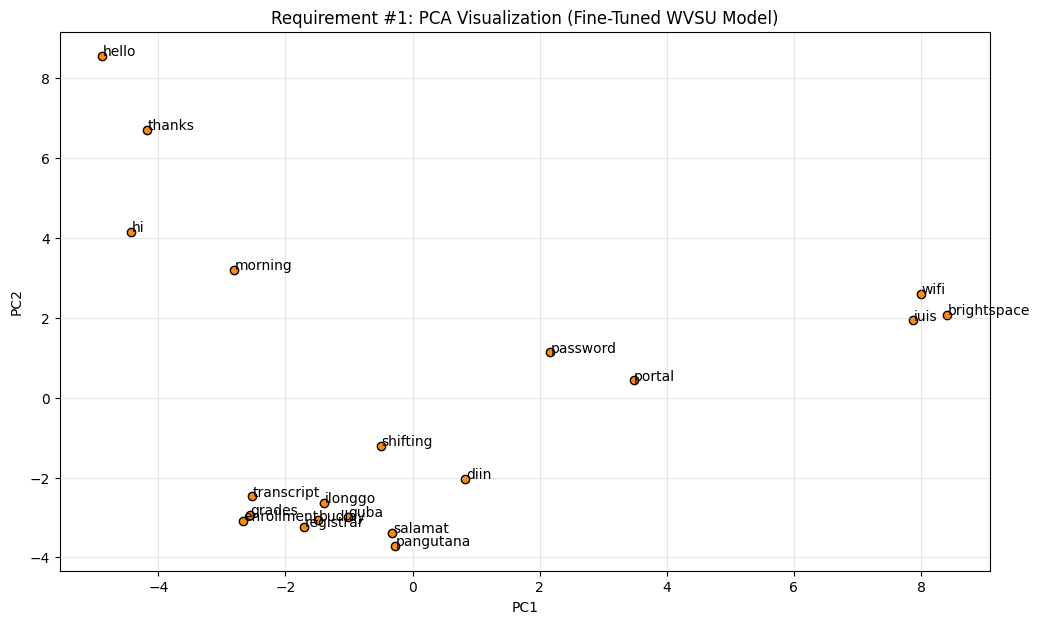

In [12]:
words = ["registrar", "enrollment", "transcript", "grades", "shifting", 
         "iuis", "brightspace", "wifi", "portal", "password",
         "salamat", "hi", "hello", "thanks", "morning",
         "diin", "guba", "budlay", "pangutana", "ilonggo"]

model.eval()
model.to("cuda")

inputs = tokenizer(words, padding=True, truncation=True, return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = model.distilbert(**inputs) # We access the base transformer layers
    # Get the 'mean' of the last hidden state for each word
    embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()

pca_tuned = PCA(n_components=2).fit_transform(embeddings)

# 4. Plotting the results
plt.figure(figsize=(12, 7))
plt.scatter(pca_tuned[:, 0], pca_tuned[:, 1], c='darkorange', edgecolors='k')

for i, word in enumerate(words):
    plt.annotate(word, (pca_tuned[i, 0] + 0.01, pca_tuned[i, 1] + 0.01), fontsize=10)

plt.title("Requirement #1: PCA Visualization (Fine-Tuned WVSU Model)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()